In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3aietf%3awg%3aoauth%3a2.0%3aoob&response_type=code&scope=email%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdocs.test%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive.photos.readonly%20https%3a%2f%2fwww.googleapis.com%2fauth%2fpeopleapi.readonly

Enter your authorization code:
··········
Mounted at /content/gdrive


In [2]:
import pandas as pd
data=pd.read_csv("/content/gdrive/My Drive/n/n_features_399_Svr.csv")

In [3]:
data=data.drop(['Unnamed: 0'], axis = 1) 

In [4]:
print(data.head())

                                           svr_input svr_values
0  [5.094589279474826, 4.332631992124425, 1.72708...  [0.63157]
1  [4.475709135047144, 4.873952332306655, 3.81767...  [0.65262]
2  [3.151692888692278, 3.1105453432527383, 2.7270...  [0.39998]
3  [8.790297444870378, 6.198691318083171, 3.87411...  [0.82105]
4  [2.8177609166718227, 2.49970502318664, 1.99985...  [0.88421]


In [5]:
print(data['svr_input'])

0        [5.094589279474826, 4.332631992124425, 1.72708...
1        [4.475709135047144, 4.873952332306655, 3.81767...
2        [3.151692888692278, 3.1105453432527383, 2.7270...
3        [8.790297444870378, 6.198691318083171, 3.87411...
4        [2.8177609166718227, 2.49970502318664, 1.99985...
                               ...                        
25801    [2.5816619784334716, 2.4096667243019585, 0.797...
25802    [1.7403045779745288, 1.7118649581850776, 1.695...
25803    [2.2175708763533972, 1.79636827193479, 1.15451...
25804    [2.2320418543830196, 2.738509507045365, 1.9323...
25805    [2.994908490944144, 2.868028556148314, 3.17505...
Name: svr_input, Length: 25806, dtype: object


In [6]:
svrinput=[]
def Convert(string): 
    li = list(string.split(",")) 
    return li 
     
for i in range(len(data['svr_input'])):
   str1 = data['svr_input'][i][1:-1]
   nums = list(map(float, Convert(str1)))

   svrinput.append(nums)
   str1=""
   nums=list()
print(len(svrinput))  

25806


In [7]:
df1=pd.DataFrame(svrinput)



In [8]:
df2=pd.read_csv('/content/gdrive/My Drive/n/scaledNForkrig.csv', sep=',',header=None)

In [9]:
print(df2.keys())

Int64Index([0, 1, 2], dtype='int64')


In [10]:
svrvalues=[]
for i in range(len(data['svr_values'])):
    svrvalues.append(float(data['svr_values'][i][1:-1]))

df1['y']= svrvalues
df1['lat']=df2[0]
df1['long']=df2[1]

print(df1)

              0         1         2  ...        y     lat    long
0      5.094589  4.332632  1.727088  ...  0.63157  17.895  73.401
1      4.475709  4.873952  3.817677  ...  0.65262  17.895  73.401
2      3.151693  3.110545  2.727079  ...  0.39998  17.895  73.402
3      8.790297  6.198691  3.874111  ...  0.82105  17.895  73.404
4      2.817761  2.499705  1.999853  ...  0.88421  17.895  73.404
...         ...       ...       ...  ...      ...     ...     ...
25801  2.581662  2.409667  0.797791  ...  0.18336  20.596  75.148
25802  1.740305  1.711865  1.695584  ...  0.10573  20.597  74.475
25803  2.217571  1.796368  1.154513  ...  0.29822  20.597  75.914
25804  2.232042  2.738510  1.932340  ...  0.24559  20.598  75.423
25805  2.994908  2.868029  3.175055  ...  0.42103  20.598  75.595

[25806 rows x 403 columns]


In [11]:
x=df1.drop(['y'], axis = 1).values
y= df1.y.values.reshape(-1,1)

In [12]:
print(x)

[[ 5.09458928  4.33263199  1.72708783 ...  0.08915298 17.895
  73.401     ]
 [ 4.47570914  4.87395233  3.81767703 ...  0.24665794 17.895
  73.401     ]
 [ 3.15169289  3.11054534  2.72707851 ...  0.39322606 17.895
  73.402     ]
 ...
 [ 2.21757088  1.79636827  1.15451272 ...  0.49800876 20.597
  75.914     ]
 [ 2.23204185  2.73850951  1.93233997 ...  0.25527698 20.598
  75.423     ]
 [ 2.99490849  2.86802856  3.17505459 ...  0.23675445 20.598
  75.595     ]]


In [13]:
print(y)

[[0.63157]
 [0.65262]
 [0.39998]
 ...
 [0.29822]
 [0.24559]
 [0.42103]]


In [14]:
from scipy.spatial import distance
from collections import OrderedDict 
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import r2_score,mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)
print(len(x_train[0]))


402


/usr/local/lib/python3.6/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [15]:
X_train=[]
for i in range(len(x_train)):
   X_train.append(x_train[i][:-2])
print(len(X_train[0]))

400


In [16]:
X_test=[]
for i in range(len(x_test)):
   X_test.append(x_test[i][:-2])
print(len(X_test[0]))

400


In [17]:
svr_rbf = SVR(kernel='linear', C=1, gamma=0.1, epsilon=.1)
svr_rbf.fit( X_train,y_train.ravel())

SVR(C=1, cache_size=200, coef0=0.0, degree=3, epsilon=0.1, gamma=0.1,
    kernel='linear', max_iter=-1, shrinking=True, tol=0.001, verbose=False)

In [18]:
y_pred=svr_rbf.predict(X_test)
print(y_pred)


[0.12219043 0.29938171 0.13160637 ... 0.30451633 0.07940108 0.33283692]


In [19]:
print(len(y_pred))

5162


In [20]:
print(y_test)
output =[]
for i in range(len(y_test)):
  output.append(y_test[i][0])
print(output)

[[0.097714]
 [0.31577 ]
 [0.15035 ]
 ...
 [0.23807 ]
 [0.12278 ]
 [0.35086 ]]
[0.097714, 0.31577, 0.15035, 0.13364, 0.24559, 0.40349, 0.14144, 0.094205, 0.25895999999999997, 0.25227, 0.20956, 0.033527, 0.14668, 0.078499, 0.68771, 0.12278, 0.29822, 0.19646, 0.15035, 0.22804000000000002, 0.40349, 0.13614, 0.24841, 0.039233, 0.17808, 0.12996, 0.24559, 0.33331, 0.28068000000000004, 0.4227, 0.10178999999999999, 0.061063, 0.20956, 0.10189, 0.19139, 0.22303, 0.18325, 0.09604299999999999, 0.1204, 0.13355999999999998, 0.17282, 0.15064, 0.24434, 0.10472999999999999, 0.19954000000000002, 0.17549, 0.35086, 0.15787, 0.1069, 0.2105, 0.14667, 0.13097, 0.030168, 0.19384, 0.71344, 0.12303, 0.19546, 0.31577, 0.28068000000000004, 0.12194, 0.49121000000000004, 0.45611999999999997, 0.33331, 0.0086553, 0.088524, 0.24559, 0.31737, 0.6491100000000001, 0.11787, 0.15192, 0.22804000000000002, 0.18336, 0.19296, 0.12215, 0.23806999999999998, 0.2199, 0.087689, 0.7017399999999999, 0.066953, 0.17174, 0.1963, 0.16789,

In [23]:
svrresults={'lat':[],'long':[],'actual':[],'predicted':[]}
for i in range(len(x_test)):
    svrresults['lat'].append(x_test[i][-2])
    svrresults['long'].append(x_test[i][-1])
svrresults['actual']=output
svrresults['predicted']=y_pred
print(svrresults['lat'])
log_df = pd.DataFrame(svrresults)
log_df.to_csv('/content/gdrive/My Drive/n/n_400_final_results.csv')



[19.028, 19.53, 18.355, 18.469, 19.646, 18.541, 18.314, 18.433, 18.29, 19.273, 18.494, 19.651, 18.178, 18.202, 19.194000000000003, 18.283, 19.524, 18.487000000000002, 18.206, 19.812, 19.504, 18.186, 18.323, 18.975, 18.28, 18.205, 18.225, 18.555999999999997, 18.449, 19.752, 18.357, 18.355, 18.486, 19.241, 18.404, 18.691, 18.385, 18.315, 18.47, 18.435, 18.343, 18.241, 18.347, 18.232, 18.324, 18.180999999999997, 19.674, 19.500999999999998, 18.407, 19.474, 18.414, 18.456, 18.537, 18.835, 19.192999999999998, 18.209, 18.257, 19.63, 19.317, 18.352, 18.48, 18.511, 19.874000000000002, 19.297, 19.278, 19.862000000000002, 20.387, 19.729, 18.174, 18.738, 18.76, 19.416, 20.314, 18.358, 19.194000000000003, 18.378, 18.113, 18.657, 18.327, 18.209, 18.835, 19.91, 18.438, 19.055, 19.512, 18.064, 18.808, 18.284000000000002, 18.006, 18.038, 19.404, 18.253, 18.389, 19.949, 18.359, 18.596, 19.07, 18.658, 18.351, 19.509, 18.372, 18.381, 18.836, 19.867, 18.257, 19.829, 18.227, 18.498, 19.109, 18.574, 18.261, 

In [24]:
def smape(A, F):
    return 1/len(A) * np.sum(2 * np.abs(F - A) / (np.abs(A) + np.abs(F)))
def manualr2(A,F):
  correlation_matrix = np.corrcoef(A,F)
  correlation_xy = correlation_matrix[0,1]
  r_squared = correlation_xy**2
  return r_squared 
print(y_test)
print(y_pred)


[[0.097714]
 [0.31577 ]
 [0.15035 ]
 ...
 [0.23807 ]
 [0.12278 ]
 [0.35086 ]]
[0.12219043 0.29938171 0.13160637 ... 0.30451633 0.07940108 0.33283692]


Int64Index([3, 4], dtype='int64')


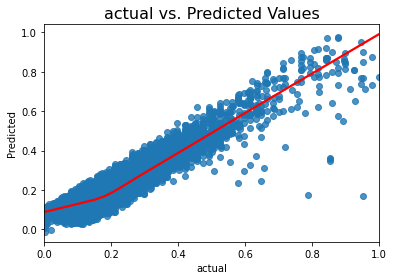

In [25]:
from sklearn import datasets
from sklearn.model_selection import cross_val_predict
from sklearn import linear_model
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
df1=pd.read_csv('/content/gdrive/My Drive/n/n_400_final_results.csv', sep=',',header=None)
df1=df1.drop([0,1,2],axis=1)
df1=df1.drop([0],axis=0)
df1.head()
print(df1.keys())
fig, ax = plt.subplots(1,1)
sns.regplot(x=list(map(float, df1[3])) , y=list(map(float, df1[4])) , lowess=True, ax=ax, line_kws={'color': 'red'})
ax.set_title('actual vs. Predicted Values', fontsize=16)
ax.set(ylabel='Predicted', xlabel='actual')
def mape(row):
    return abs(row.Forecast - row.Actual) / ((abs(row.Actual) + abs(row.Forecast))/2)

# create the pandas dataframe if you dont have one already
df=pd.DataFrame.from_dict({'Actual':list(map(float, df1[3])), 'Forecast':list(map(float, df1[4]))})

# apply the above function on each row 
smape = df.apply(mape, axis=1).sum() * (1/len(df))


In [26]:
val_dict = dict()
val_dict['rmse']=[]
val_dict['r2']=[]
val_dict['manualr2']=[]
val_dict['smape']=[]
val_dict['mae']=[]
rmse_list =[]
r2_list =[]
mae_list =[]
smape_list =[]
rmse_list.append( sqrt(mean_squared_error(y_pred ,output )))
# smape_list.append(smape(y_pred , output ))
r2_list.append(r2_score(y_pred , output ))
mae_list.append(mean_absolute_error(y_pred , output ))

val_dict['rmse'].append(rmse_list)
val_dict['r2'].append(svr_rbf.score(X_test, output))
val_dict['manualr2'].append(manualr2(y_pred,output))
val_dict['mae'].append(mae_list)
val_dict['smape'].append(smape)
log_df = pd.DataFrame(val_dict)
log_df.to_csv('/content/gdrive/My Drive/n/n_val_r.csv')
